# Pyramid Chart

This section showcases the pyramid chart. It contains examples of how to create the pyramid chart using the [datachart.charts.PyramidChart](../../../references/charts/#datachart.charts.PyramidChart) function.

A pyramid chart draws exactly two data series as horizontal bars extending in opposite directions from a shared zero line — the classic population-pyramid layout, useful whenever two groups are compared over the same categories.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-pyramid-chart), which maps common tasks to the parameter or style attribute that does the job.

As mentioned above, the pyramid charts are created using the `PyramidChart` function found in the [datachart.charts](../../../references/charts/) module. Let's import it:

In [1]:
from datachart.charts import PyramidChart

## Pyramid Chart Input Attributes

The `PyramidChart` function accepts keyword arguments for chart configuration. The main argument is `data`, which contains exactly two lists of data points: the first list is the left side of the pyramid, the second the right. Both sides are supplied as positive values — the chart mirrors the left side itself, and every visible number (value ticks, value labels) shows the absolute value.

Unlike the other chart functions, the axis parameters are spatial: `xlabel`, `xticks`, and `xmax` address the horizontal value axis, and `ylabel` the vertical category axis. The value axis is always symmetric around zero, so there is no `xmin`.

```python
PyramidChart(
    data=[[{                                        # Exactly two lists of data points: [left_side, right_side]
        "label": str,                               # The category label (shared by both sides)
        "y":     Union[int, float],                 # The bar value, positive for both sides
        "yerr":  Optional[Union[int, float]]        # The bar error value
    }], [...]],
    style={                                         # The style of the bars (optional); a list styles each side
        "plot_bar_*": ...,
    },
    subtitle=Optional[List[str]],                   # The names of the two sides, used as legend labels
    title=Optional[str],                            # The title of the chart
    xlabel=Optional[str],                           # The label of the horizontal value axis
    ylabel=Optional[str],                           # The label of the vertical category axis

    figsize=Optional[Tuple[float, float]],          # The figure size in inches
    show_grid=Optional[str],                        # Which grid lines to show ("both", "x", "y")
    show_legend=Optional[bool],                     # Whether to show the legend
    show_yerr=Optional[bool],                       # Whether to show error bars on the bars
    show_values=Optional[bool],                     # Whether to show bar value labels at the bar ends
    value_format=Optional[str],                     # Format of the value labels (VALUE_FORMAT constant or e.g. "{:.1f}%")

    xmax=Optional[Union[int, float]],               # The maximum per-side value; the value axis spans (-xmax, xmax)
    xticks=Optional[List[Union[int, float]]],       # Custom value-axis tick positions, positive; mirrored to both halves
    xticklabels=Optional[List[str]],                # Custom value-axis tick labels, applied to both halves
    xtickrotate=Optional[int],                      # Rotation angle of the value-axis tick labels
    yticks=Optional[List[Union[int, float]]],       # Custom category-axis tick positions
    yticklabels=Optional[List[str]],                # Custom category-axis tick labels
    ytickrotate=Optional[int],                      # Rotation angle of the category-axis tick labels

    vlines=Optional[VLinePlotAttrs],                # The vertical lines to draw
    hlines=Optional[HLinePlotAttrs],                # The horizontal lines to draw

    label=Optional[str],                            # The data key for the labels (default: "label")
    y=Optional[str],                                # The data key for the bar values (default: "y")
    yerr=Optional[str]                              # The data key for the bar errors (default: "yerr")
)
```

For more details, see the [datachart.charts.PyramidChart](../../../references/charts/#datachart.charts.PyramidChart) function.

## Basics

The examples in this guide share one dataset: a city library system's annual visitor survey. The data is hard-coded in a hidden cell; `city_branch` and `suburban_branch` hold the share of registered members in each age band at the two branches (with the survey's sampling error as `yerr`), and `weekday_visits`/`weekend_visits` hold average daily visits per activity.

In [2]:
AGE_BANDS = ["0-14", "15-29", "30-44", "45-59", "60-74", "75+"]

# share of registered members per age band (%), with the sampling error
CITY = [11.8, 24.6, 22.9, 17.4, 14.2, 9.1]
SUBURB = [19.5, 14.1, 23.7, 18.2, 15.9, 8.6]
CITY_ERR = [1.1, 1.6, 1.5, 1.3, 1.2, 0.9]
SUBURB_ERR = [1.4, 1.2, 1.6, 1.3, 1.2, 0.9]
city_branch = [
    {"label": a, "y": v, "yerr": e} for a, v, e in zip(AGE_BANDS, CITY, CITY_ERR)
]
suburban_branch = [
    {"label": a, "y": v, "yerr": e} for a, v, e in zip(AGE_BANDS, SUBURB, SUBURB_ERR)
]

# average daily visits per activity
ACTIVITIES = ["Borrowing", "Study space", "Events", "Computer use", "Newspapers"]
weekday_visits = [
    {"label": a, "y": v} for a, v in zip(ACTIVITIES, [310, 465, 85, 140, 95])
]
weekend_visits = [
    {"label": a, "y": v} for a, v in zip(ACTIVITIES, [420, 205, 240, 90, 130])
]

Each data point is a dictionary with a `label` (the age band) and a positive `y` value; the same labels appear on both sides:

In [3]:
city_branch[:3]

[{'label': '0-14', 'y': 11.8, 'yerr': 1.1},
 {'label': '15-29', 'y': 24.6, 'yerr': 1.6},
 {'label': '30-44', 'y': 22.9, 'yerr': 1.5}]

**Basic example.** Only the `data` argument is required — exactly two lists of data points, the first drawn to the left and the second to the right.

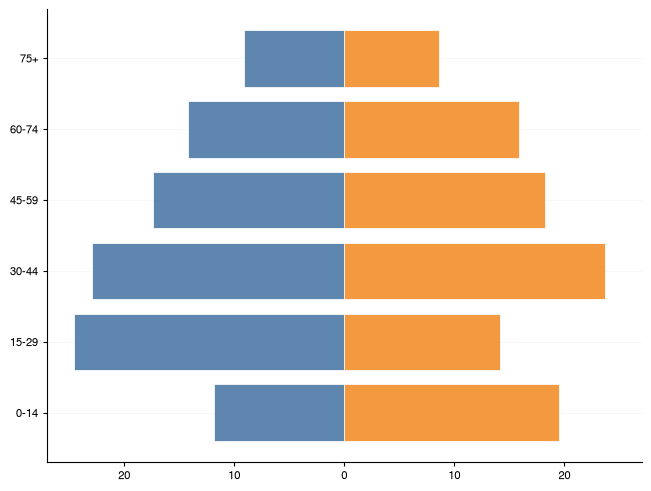

In [4]:
PyramidChart(
    # add the two sides of the pyramid: [left_side, right_side]
    data=[city_branch, suburban_branch]
).show()

Both sides extend from the shared zero line at full bar width, the category labels sit at the left edge, and the value ticks show absolute values on both halves.

## Customizing the Pyramid Chart

Every customization is either a keyword argument of `PyramidChart` or a style attribute of its `style` dictionary. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                | Use                                                | See |
| :---------------------------------------- | :------------------------------------------------- | :-- |
| add a title and axis labels               | `title`, `xlabel`, `ylabel`                        | [Title and axis labels](#title-and-axis-labels) |
| name the two sides                        | `subtitle`, `show_legend`                          | [Naming the sides](#naming-the-sides) |
| resize the figure or show the grid        | `figsize`, `show_grid`                             | [Figure size and grid](#figure-size-and-grid) |
| fix the value range or its ticks          | `xmax`, `xticks`, `xticklabels`                    | [Value axis limits and ticks](#value-axis-limits-and-ticks) |
| write each bar's value at its end         | `show_values`, `value_format`                      | [Value labels](#value-labels) |
| show the error bars                       | `show_yerr`                                        | [Error bars](#error-bars) |
| style the bars, per side                  | `style`                                            | [Bar style](#bar-style) |
| use my own data keys                      | `label`, `y`, `yerr`                               | [Custom data keys](#custom-data-keys) |

### Title and axis labels

To add the chart title and axis labels, add the `title`, `xlabel` and `ylabel` attributes. The axis parameters are spatial: `xlabel` describes the horizontal value axis and `ylabel` the vertical category axis.

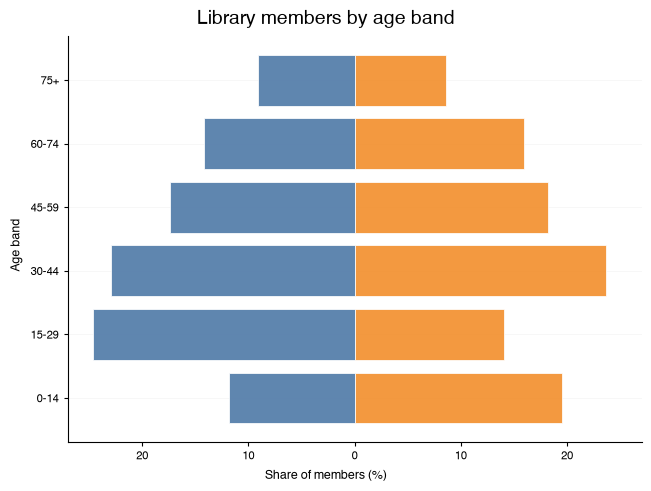

In [5]:
PyramidChart(
    data=[city_branch, suburban_branch],
    # add the title and the axis labels
    title="Library members by age band",
    xlabel="Share of members (%)",
    ylabel="Age band",
).show()

### Naming the sides

The `subtitle` attribute names the two sides, in the same order as `data`; with `show_legend=True` the names appear in the legend.

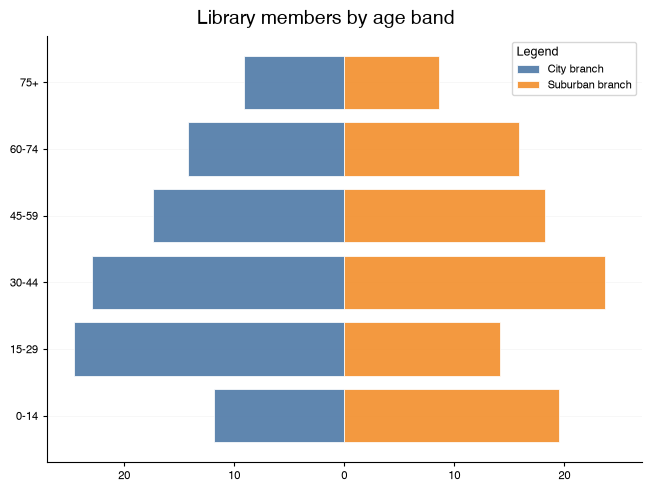

In [6]:
PyramidChart(
    data=[city_branch, suburban_branch],
    # name the sides and show the legend
    subtitle=["City branch", "Suburban branch"],
    show_legend=True,
    title="Library members by age band",
).show()

### Figure size and grid

The figure size is set with `figsize` — the [datachart.constants](../../../references/constants) module provides the `FIG_SIZE` options — and the grid is turned on with `show_grid`. On a pyramid the vertical grid lines (`"x"`) are usually the useful ones, since they mark the value steps on both halves.

In [7]:
from datachart.constants import FIG_SIZE, SHOW_GRID

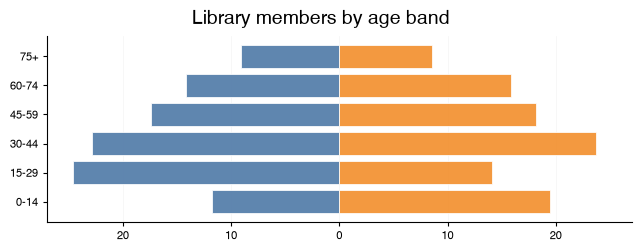

In [8]:
PyramidChart(
    data=[city_branch, suburban_branch],
    title="Library members by age band",
    # resize the figure and show the vertical grid lines
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.X,
).show()

### Value axis limits and ticks

The value axis is always symmetric around zero. The `xmax` attribute sets the maximum per-side value, so the axis spans `(-xmax, xmax)`; passing `xmin` raises a `ValueError`.

The `xticks` attribute places custom value ticks: the positions are given as positive values and each is mirrored to both halves. The `xticklabels` attribute (same length as `xticks`) replaces the tick labels on both halves, and `xtickrotate` rotates them. The category axis keeps the usual `yticks`, `yticklabels`, and `ytickrotate` controls.

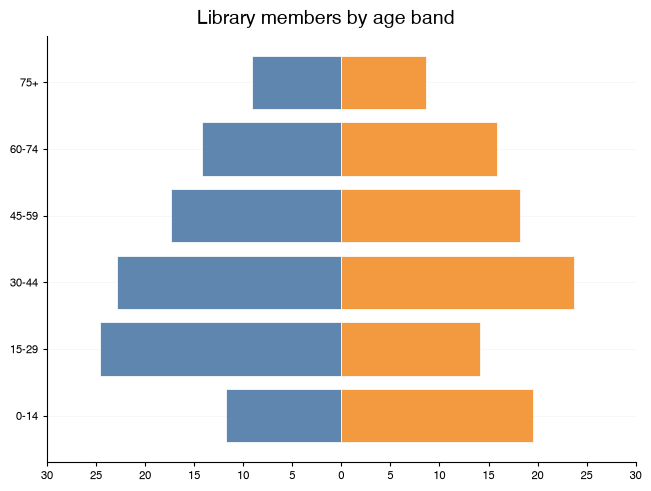

In [9]:
PyramidChart(
    data=[city_branch, suburban_branch],
    title="Library members by age band",
    # give both sides the same fixed range and label every fifth percent
    xmax=30,
    xticks=[0, 5, 10, 15, 20, 25, 30],
).show()

### Value labels

The `show_values` attribute writes each bar's value at its end, formatted via `value_format` — a `VALUE_FORMAT` constant or any printf/format-style string. The labels show the absolute value on both sides.

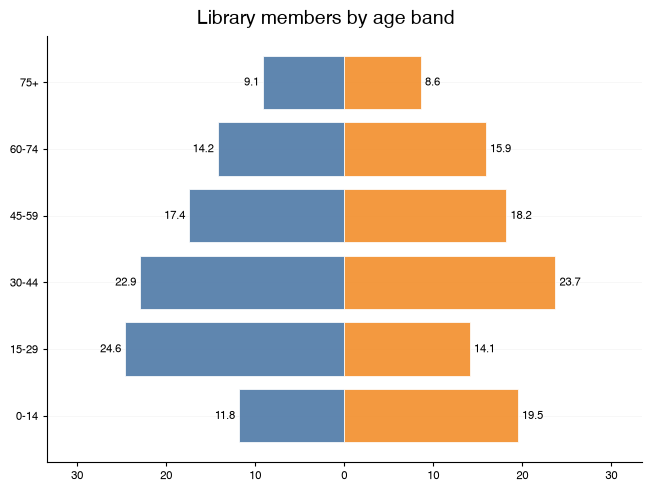

In [10]:
PyramidChart(
    data=[city_branch, suburban_branch],
    title="Library members by age band",
    # write each bar's share at its end
    show_values=True,
    value_format="%.1f",
).show()

### Error bars

The `show_yerr` attribute draws the `yerr` values as error bars at the bar ends — on a pyramid they extend along the value axis, symmetrically on both sides of the bar end.

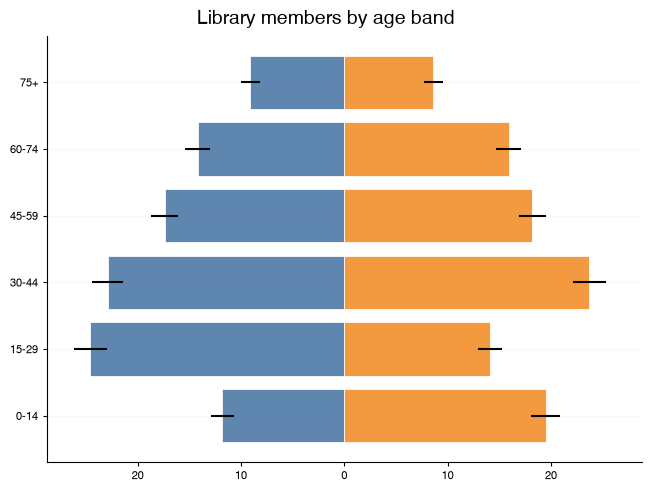

In [11]:
PyramidChart(
    data=[city_branch, suburban_branch],
    title="Library members by age band",
    # draw the sampling error at the bar ends
    show_yerr=True,
).show()

### Bar style

Pyramid bars obey the same `plot_bar_*` style attributes as the bar chart; see the [datachart.typings](../../../references/typings) module for the full family. A single `style` dictionary applies to both sides; a list of two styles the sides individually. Without explicit colors, the two sides take the first two colors of the theme's palette — themes therefore style pyramids out of the box.

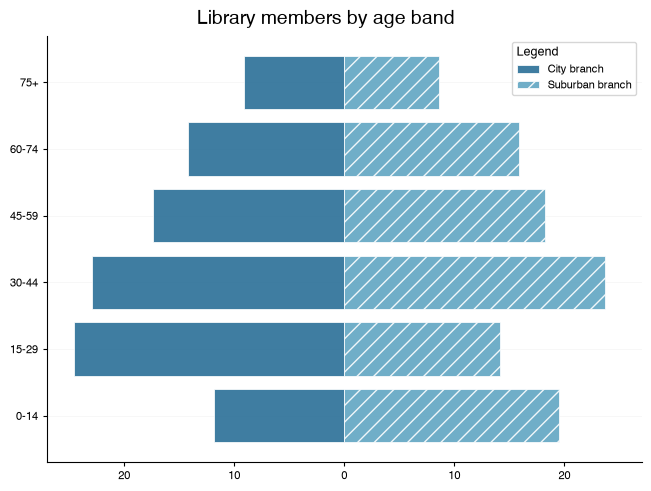

In [12]:
PyramidChart(
    data=[city_branch, suburban_branch],
    subtitle=["City branch", "Suburban branch"],
    show_legend=True,
    title="Library members by age band",
    # style each side individually
    style=[
        {"plot_bar_color": "#2a6f97", "plot_bar_alpha": 0.9},
        {"plot_bar_color": "#61a5c2", "plot_bar_hatch": "//"},
    ],
).show()

### Custom data keys

If the data points use different key names, the `label`, `y`, and `yerr` attributes remap them — either one name for both sides or a list of two.

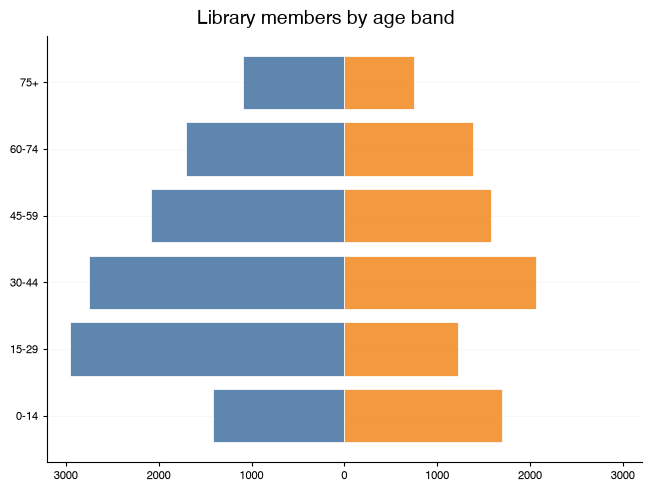

In [13]:
city_counts = [
    {"band": a, "members": round(v * 120)} for a, v in zip(AGE_BANDS, CITY)
]
suburb_counts = [
    {"band": a, "members": round(v * 87)} for a, v in zip(AGE_BANDS, SUBURB)
]

PyramidChart(
    data=[city_counts, suburb_counts],
    # remap the data keys
    label="band",
    y="members",
    title="Library members by age band",
).show()

## Composing Pyramids

One `PyramidChart` call makes one pyramid. For small multiples, compose rendered figures with [datachart.utils.Grid](../../../references/utils#datachart.utils.Grid) — each pyramid keeps its mirrored axis inside its own cell. Overlaying a pyramid onto other charts with [datachart.utils.Panel](../../../references/utils#datachart.utils.Panel) is not supported and raises a `ValueError`, since unmirrored data on a mirrored axis would be misleading.

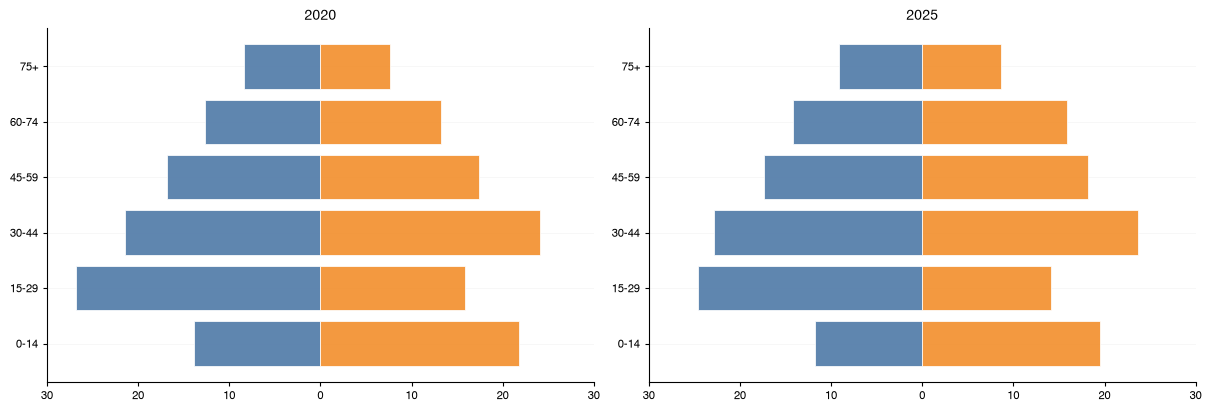

In [14]:
from datachart.utils import Grid

# the same survey five years apart
city_2020 = [
    {"label": a, "y": v}
    for a, v in zip(AGE_BANDS, [13.9, 26.8, 21.4, 16.8, 12.7, 8.4])
]
suburb_2020 = [
    {"label": a, "y": v}
    for a, v in zip(AGE_BANDS, [21.8, 15.9, 24.1, 17.4, 13.2, 7.6])
]

Grid(
    [
        PyramidChart(
            data=[city_2020, suburb_2020],
            subtitle=["City", "Suburban"],
            title="2020",
            xmax=30,
        ),
        PyramidChart(
            data=[city_branch, suburban_branch],
            subtitle=["City", "Suburban"],
            title="2025",
            xmax=30,
        ),
    ],
    max_cols=2,
    figsize=(12, 4),
).show()

## Saving the Chart as an Image

To save the chart as an image, use the [datachart.utils.save_figure](../../../references/utils#datachart.utils.save_figure) function.

In [15]:
from datachart.utils import save_figure

In [16]:
figure = PyramidChart(
    data=[city_branch, suburban_branch],
    title="Library members by age band",
)
save_figure(figure, "./fig_pyramid_chart.png", dpi=300)

The figure should be saved in the current working directory.

## Real-World Examples

### Example 1: Membership Pyramid

The full survey figure: both branches over the age bands, with named sides, a fixed symmetric range, value labels, and vertical grid lines.

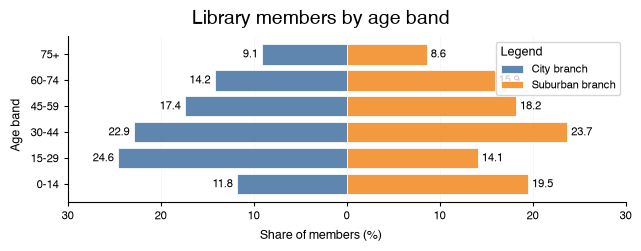

In [17]:
PyramidChart(
    data=[city_branch, suburban_branch],
    subtitle=["City branch", "Suburban branch"],
    title="Library members by age band",
    xlabel="Share of members (%)",
    ylabel="Age band",
    xmax=30,
    show_values=True,
    value_format="%.1f",
    show_legend=True,
    show_grid=SHOW_GRID.X,
    figsize=FIG_SIZE.FULL_SHORT,
).show()

### Example 2: Weekday vs Weekend Visits

The same layout works for any two-group comparison — here the average daily visits per activity, weekdays against weekends. Sorting the categories by one side makes the contrast easy to read.

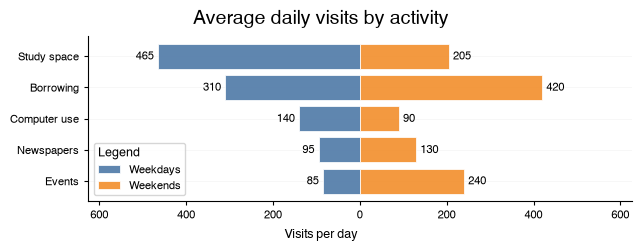

In [18]:
by_weekday = sorted(
    zip(weekday_visits, weekend_visits), key=lambda pair: pair[0]["y"]
)

PyramidChart(
    data=[[w for w, _ in by_weekday], [e for _, e in by_weekday]],
    subtitle=["Weekdays", "Weekends"],
    title="Average daily visits by activity",
    xlabel="Visits per day",
    show_values=True,
    show_legend=True,
    figsize=FIG_SIZE.FULL_SHORT,
).show()